In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [18]:
df = pd.read_csv('data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [19]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [20]:
df['waterfront'].value_counts()

waterfront
0    4567
1      33
Name: count, dtype: int64

In [21]:
#dropping country and streets for no and too much variance also date coz all belong to same year
df = df.drop(['date','country','street'],axis=1)

In [22]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [23]:
df['yr_renovated'] = np.where(df['yr_renovated'].eq(0), df['yr_built'], df['yr_renovated'])

In [24]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,1985.042609
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,26.863922
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,1900.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,1973.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,1994.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,2005.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [25]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,1921,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,1966,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,1963,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052


In [ ]:
counts = df['city'].map(df['city'].value_counts())
freq = counts / len(df)
df['city_count'] = counts
df['city_freq']  = freq
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,city_count,city_freq
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,123,0.026739
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,1921,Seattle,WA 98119,1573,0.341957
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,1966,Kent,WA 98042,185,0.040217
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,1963,Bellevue,WA 98008,286,0.062174
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,235,0.051087


In [27]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city_count,city_freq
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,1985.042609,643.991739,0.139998
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,26.863922,673.486584,0.146410
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,1900.000000,1.000000,0.000217
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,1973.000000,123.000000,0.026739
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,1994.000000,235.000000,0.051087
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,2005.000000,1573.000000,0.341957
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,1573.000000,0.341957


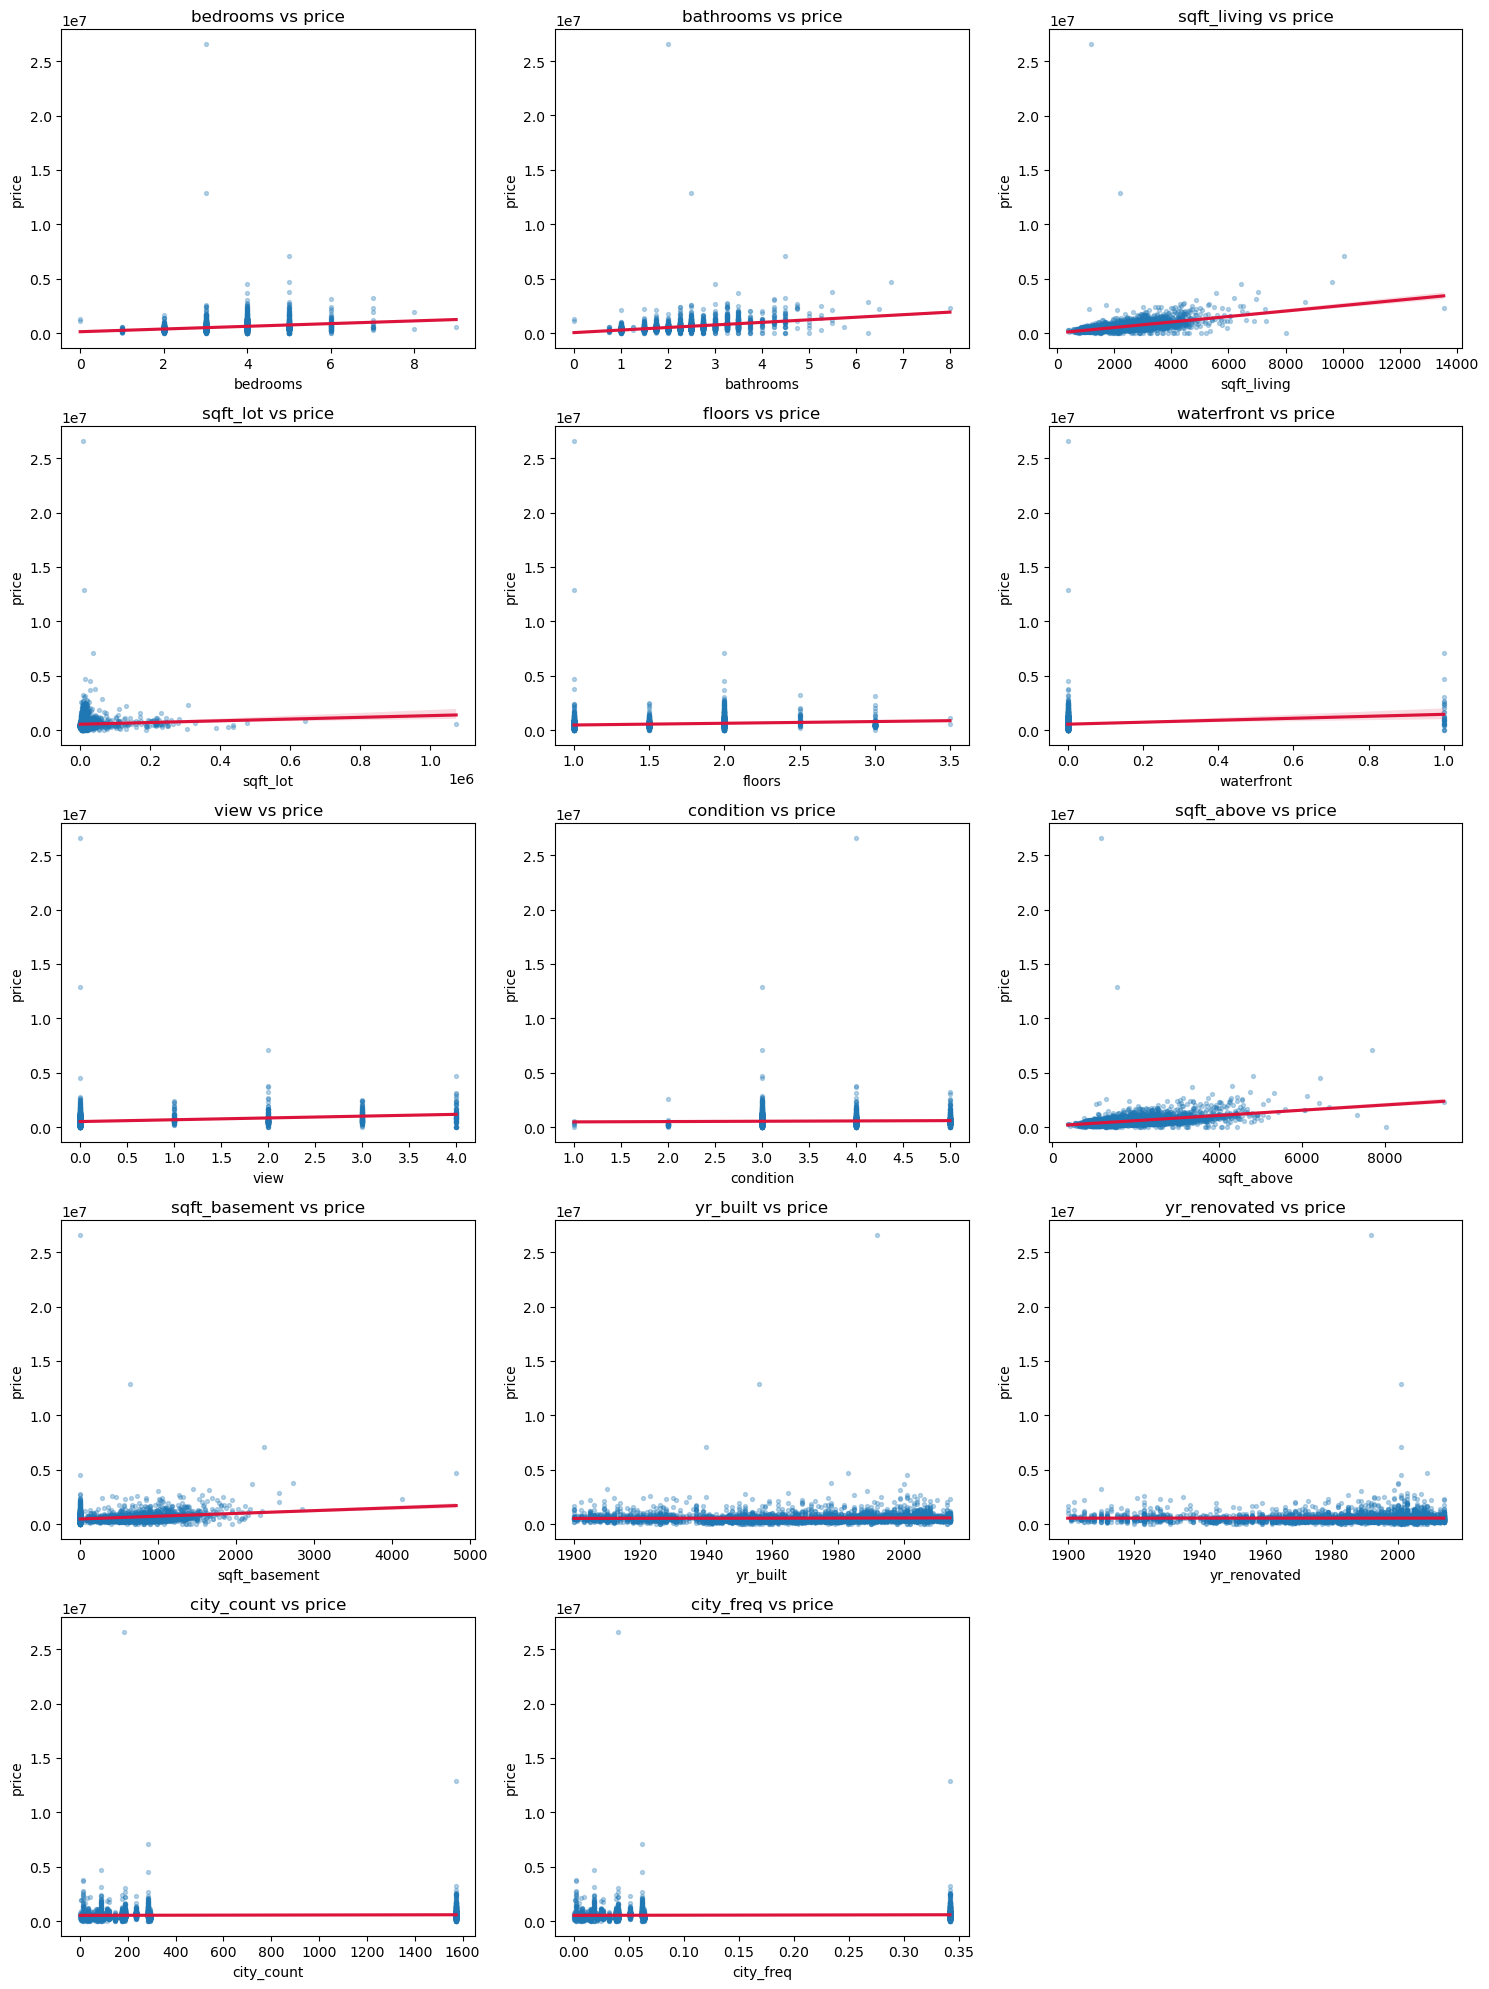

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
num = df.select_dtypes(include='number').columns.tolist()
num = [c for c in num if c != 'price' and df[c].ndim == 1]
n = len(num); cols = 3; rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.ravel()
for i, col in enumerate(num):
    sns.regplot(data=df, x=col, y='price', scatter_kws={'s':8,'alpha':0.3}, line_kws={'color':'crimson'}, ax=axes[i])
    axes[i].set_title(f'{col} vs price')
for j in range(i+1, rows*cols):
    fig.delaxes(axes[j])
plt.tight_layout(); plt.show()




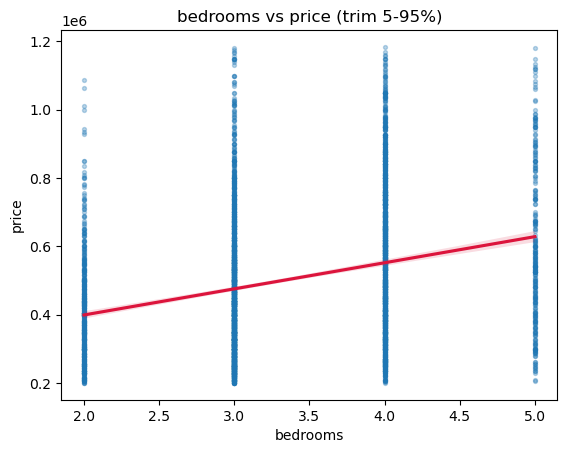

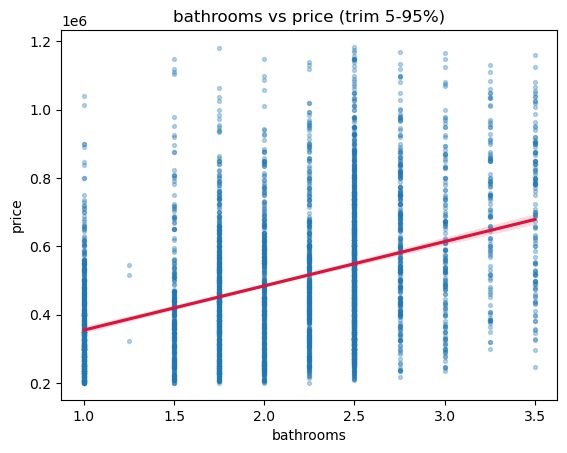

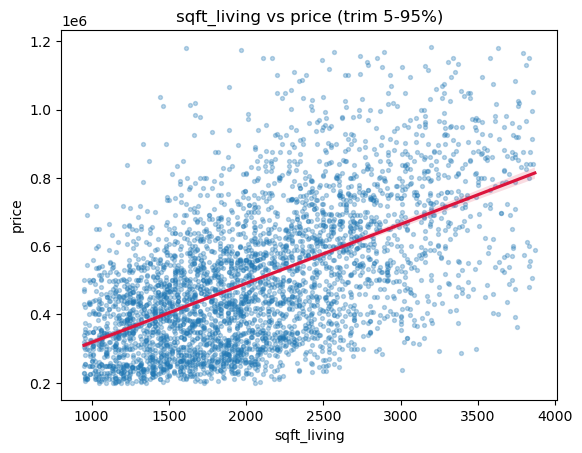

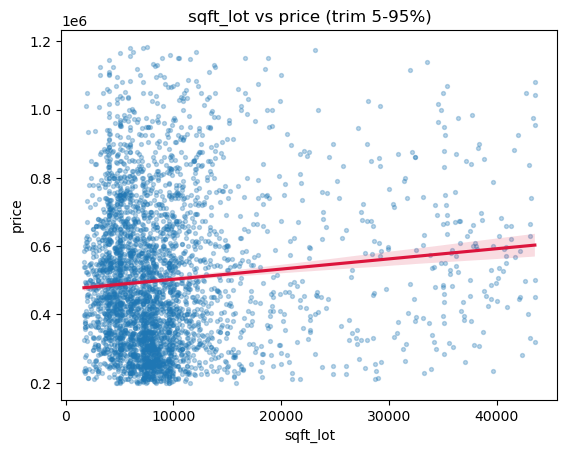

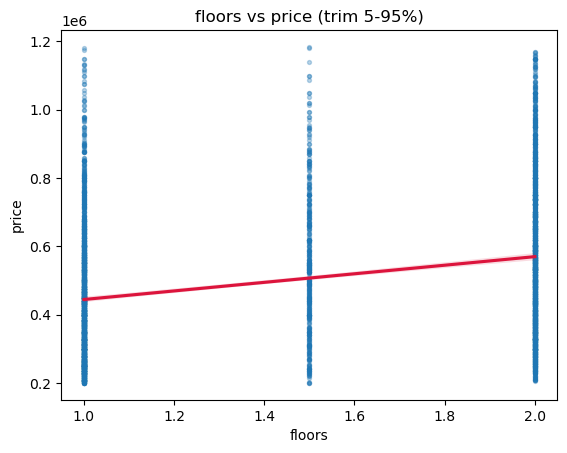

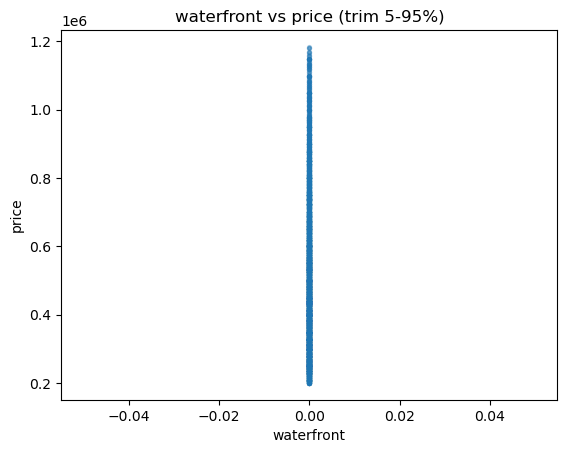

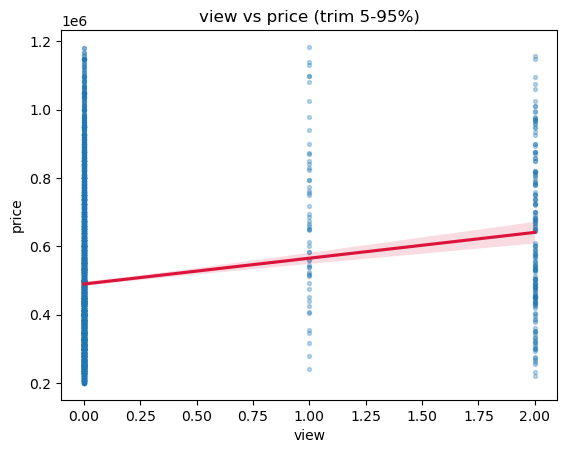

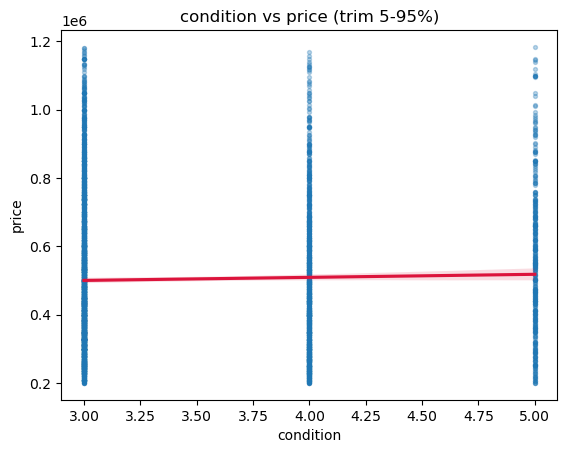

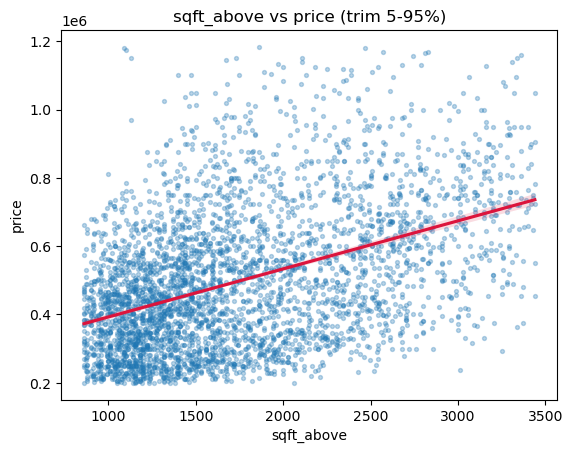

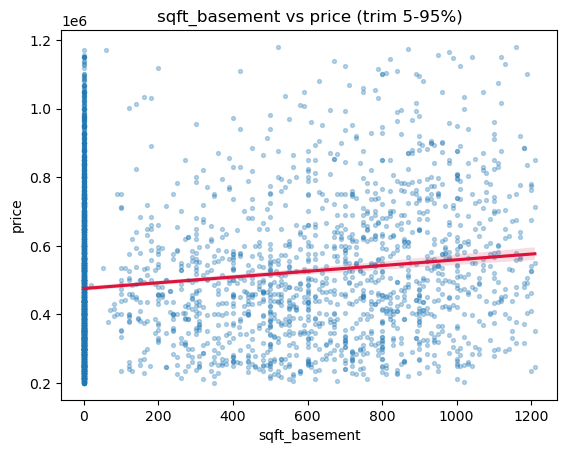

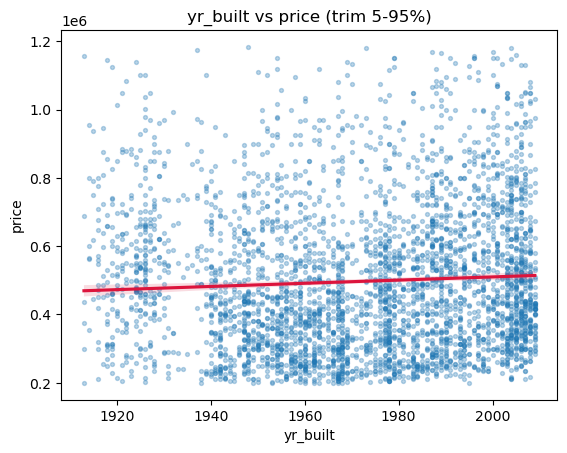

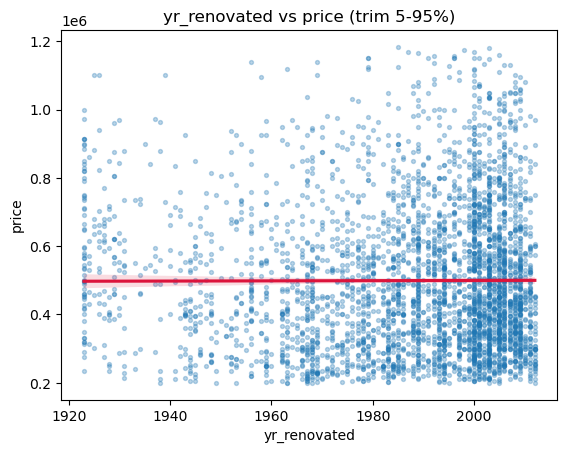

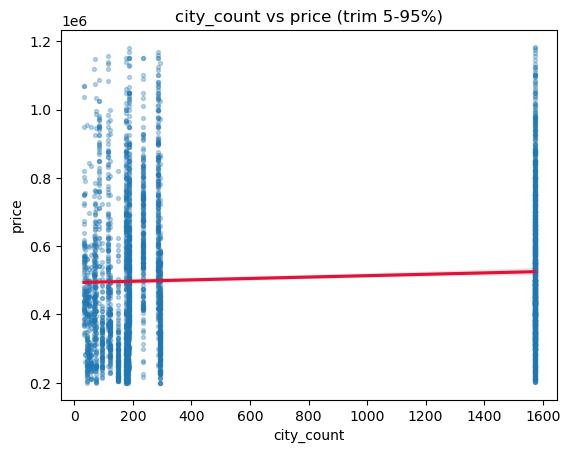

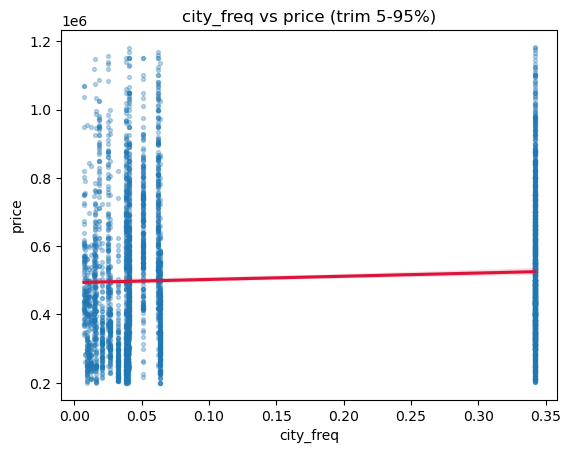

In [45]:
import numpy as np

def trim_xy(df, x, y='price', q=0.05):
    x_low, x_high = df[x].quantile([q, 1-q])
    y_low, y_high = df[y].quantile([q, 1-q])
    m = df[x].between(x_low, x_high) & df[y].between(y_low, y_high)
    return df.loc[m, [x, y]]

# Example in loop with regplot
num_cols = [c for c in df.select_dtypes(include='number').columns if c != 'price']
for col in num_cols:
    d = trim_xy(df, col, 'price', q=0.05)
    sns.regplot(data=d, x=col, y='price', scatter_kws={'s':8,'alpha':0.3}, line_kws={'color':'crimson'})
    plt.title(f'{col} vs price (trim 5-95%)')
    plt.show()


# Insights:
1. Bedrooms and price show a linear relation
2. Same for bathroom and price
3. Same for sqft living and price
4. for sqft lot and price there's a log type relation most prices aggrgate at smaller sqft but as it increases there's a small increase in price
5. floors also have increasing linear relation with price 
6. for 0 waterfront there's no effect while price increases just a little bit if there's waterfront
7. view also has a barely present linear relation with price
8. non existent impact of condition on price
9. sqft basement and sqft above have a linear relation with price
10. yr built and yr renovated do have a impact with yr inovated having more impact on price
11. for city count and frq certain values show a bump in price corresponding to popular cities.

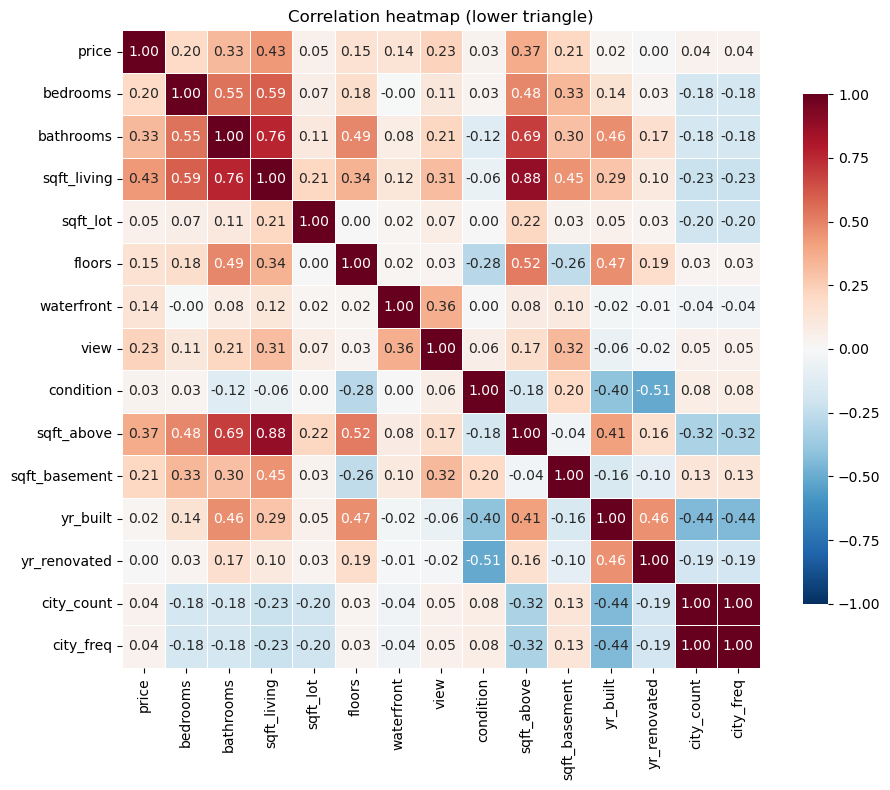

In [48]:
corr = df.select_dtypes(include='number').corr()

# Mask upper triangle (including diagonal)
# mask = np.triu(np.ones_like(corr, dtype=bool), k=0)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, annot=True, fmt='.2f',
    linewidths=0.5, square=True, cbar_kws={'shrink': .8}
)
plt.title('Correlation heatmap (lower triangle)')
plt.tight_layout()
plt.show()

In [51]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,statezip,city_count,city_freq
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,WA 98133,123,0.026739
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,1921,WA 98119,1573,0.341957
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,1966,WA 98042,185,0.040217
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,1963,WA 98008,286,0.062174
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,WA 98052,235,0.051087


In [57]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# import numpy as np
# df = df.drop(columns=['statezip'])
X, y = df.drop(columns=['price']), df['price']
model = make_pipeline(StandardScaler(with_mean=False), LinearRegression())
# models = [
#     ('LR', make_pipeline(StandardScaler(with_mean=False), LinearRegression())),
#     ('Ridge', make_pipeline(StandardScaler(with_mean=False), Ridge(alpha=10.0))),
#     ('Lasso', make_pipeline(StandardScaler(with_mean=False), Lasso(alpha=0.01, max_iter=5000))),
#     ('ENet', make_pipeline(StandardScaler(with_mean=False), ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000))),
# ]
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# for name, model in models:
#     rmse = (-cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=cv)).mean()
#     print(name, 'CV RMSE:', rmse)

-cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=cv)

array([990913.3803793 , 218376.89186176, 277639.02689963, 258442.01750005,
       262833.16059555])